## FlexUOD Extension Experiment Code

### Imports

In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import os
from sklearn.metrics import roc_auc_score
from dataloader import dataLoader, load_data_with_outliers, extract_resnet50_feature
from method import DaDTAnomalyDetector
from new_method import predict_labels, predict_scores
import matplotlib.pyplot as plt
import cv2
import time
import os
import asyncio
import timeit

### Accuracy Comparison

In [6]:
dataset_indexes = [0, 1, 2, 7]
feature_type = "ResNet"

clf = DaDTAnomalyDetector()  # Original FlexUOD method

for index in dataset_indexes:
    all_feats, all_labels, dataset_name = dataLoader(index, feature_type)
    print('\n\ndataset: ', dataset_name)
    
    target_class = 0
    p_anon = 0.3

    data, gt = load_data_with_outliers(all_feats, all_labels, target_class, p_anon)
    
    print("Data Size:", data.shape)
    orig_scores = clf.dadt_(data)
    new_scores, _ = predict_scores(data)
    orig_auc = roc_auc_score(gt, orig_scores)
    new_auc = roc_auc_score(gt, new_scores)
    print('FlexUOD AUC: ', format(orig_auc, '.3f'))
    print('FlexUOD Extension AUC: ', format(new_auc, '.3f'))
    
    
    



dataset:  STL-10
Data Size: (1857, 2048)
FlexUOD AUC:  0.993
FlexUOD Extension AUC:  0.993
feature type:  ResNet


dataset:  CIFAR-10
Data Size: (8571, 2048)
FlexUOD AUC:  0.945
FlexUOD Extension AUC:  0.945
feature type:  ResNet


dataset:  MIT-Places-Small
Data Size: (4437, 2048)
FlexUOD AUC:  0.936
FlexUOD Extension AUC:  0.936
feature type:  ResNet


dataset:  CIFAR-100
Data Size: (857, 2048)
FlexUOD AUC:  0.978
FlexUOD Extension AUC:  0.978


### Speedup Tests

In [7]:
# Data Collection

all_feats, _, _ = dataLoader(1, 'ResNet')  # index 1 is CIFAR-10

num_feats = [1_000, 5_000, 10_000, 25_000, 50_000]
width = 0.4

y_old = []
y_new = []
num_runs = 20
for num_feat in num_feats:
    chunk = all_feats[:num_feat]
    y_old.append(timeit.timeit("clf.dadt_(chunk)", number=num_runs, globals=globals()) / num_runs)
    y_new.append(timeit.timeit("predict_scores(chunk)", number=num_runs, globals=globals()) / num_runs)
    

feature type:  ResNet


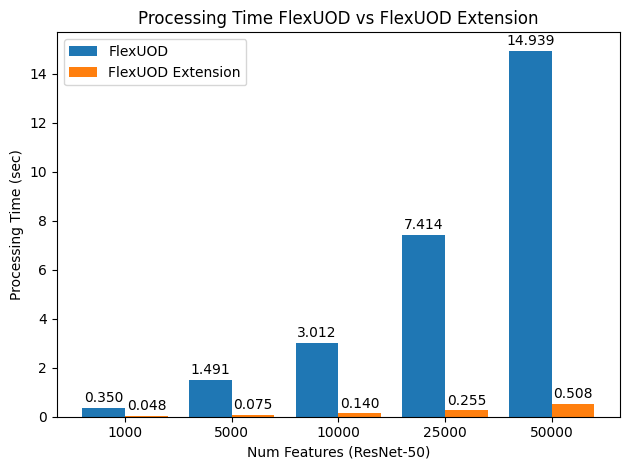

In [9]:
# Bar Chart

x = np.arange(len(num_feats))

# plt.figure(figsize=(4,3))
bars_old = plt.bar(x-0.2, y_old, width, label="FlexUOD")
plt.bar_label(bars_old, padding=2, fmt="%.3f")
bars_new = plt.bar(x+0.2, y_new, width, label="FlexUOD Extension")
plt.bar_label(bars_new, padding=2, fmt="%.3f")
plt.legend()
plt.xticks(x, num_feats)
plt.xlabel("Num Features (ResNet-50)")
plt.ylabel("Processing Time (sec)")
plt.title("Processing Time FlexUOD vs FlexUOD Extension")
plt.tight_layout()
plt.show()

Average Speedup: 21.436246782909713


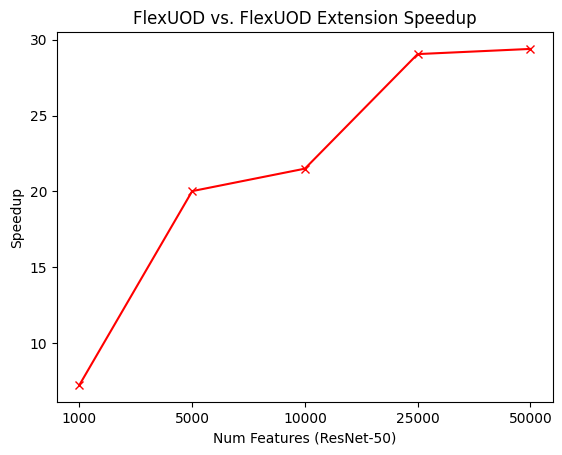

In [12]:
# Speedup Plot

speedup = np.array(y_old) / np.array(y_new)

print("Average Speedup:", np.mean(speedup))

plt.title("FlexUOD vs. FlexUOD Extension Speedup")
plt.plot(x, speedup, "r-x")
plt.xticks(x, num_feats)
plt.xlabel("Num Features (ResNet-50)")
plt.ylabel("Speedup")
plt.show()

### Generated Video Analysis

This test is located in the `fake_video_test.py` file. This is partially because Jupyter Notebooks have a memory limit, which this test likely exceeds.